In [20]:
print("\n TASK 3: Sales Prediction using Python \n")


 TASK 3: Sales Prediction using Python 



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Advertising (1).csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.shape

(200, 5)

In [7]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

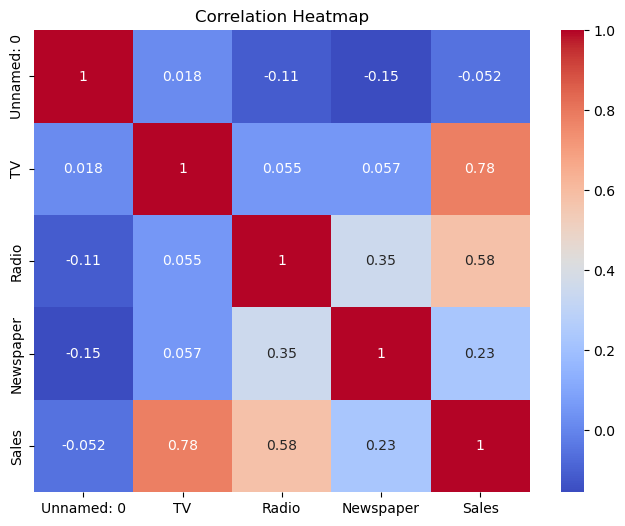

In [8]:
#Exploratory Data Analysis
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

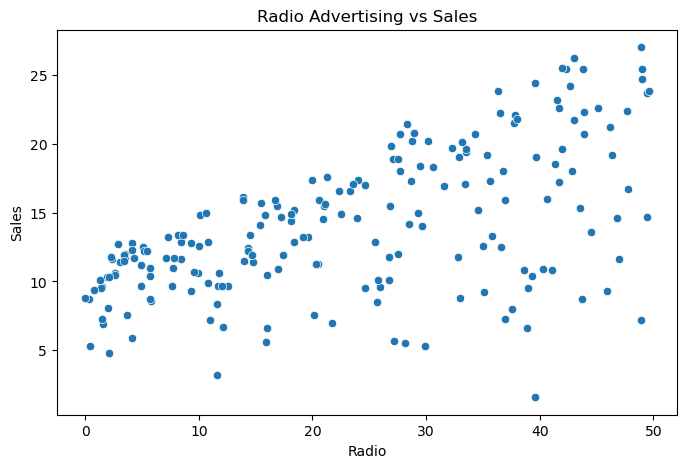

In [9]:
#Sales vs Radio Advertising
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Radio',
    y='Sales',
    data=df
)
plt.title("Radio Advertising vs Sales")
plt.show()

In [10]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
predictions = model.predict(X_test)

print(predictions[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [17]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\n MAE :", mae)
print("\n MSE :", mse)
print("\n RMSE :", rmse)
print("\n R2 Score :", r2)


 MAE : 1.4607567168117606

 MSE : 3.1740973539761055

 RMSE : 1.7815996615334506

 R2 Score : 0.899438024100912


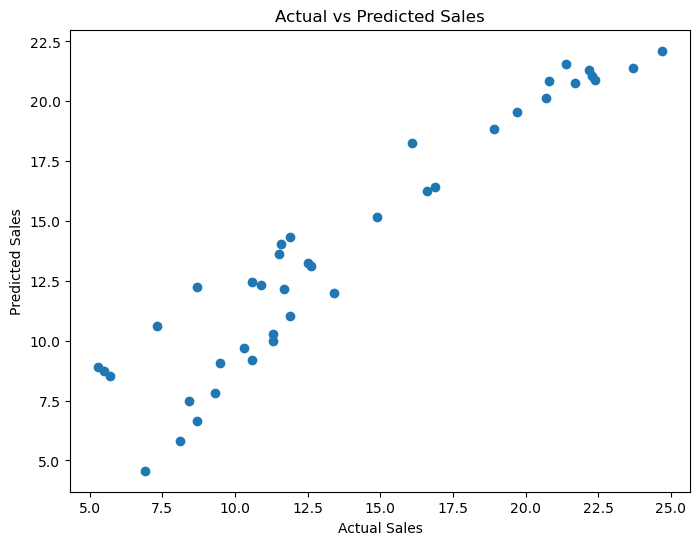

In [18]:
#Actual vs Predicted Sales
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [19]:
#Advertising Impact Analysis
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_
})
print(coefficients)

     Feature    Impact
0         TV  0.044730
1      Radio  0.189195
2  Newspaper  0.002761
